In [3]:
import torch
import gpytorch
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from utils.utils import get_city_map, load_city_data, get_sensor_locations

# Target City: Fresno

## Grid Map

In [4]:
fresno_map = get_city_map("Fresno")
fresno_map

,STATEFP,PLACEFP,PLACENS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,PCINECTA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
274,06,27000,02410546,0627000,Fresno,Fresno city,25,C1,Y,N,G4110,A,296267437,732167,+36.7836027,-119.7934453,"MULTIPOLYGON (((-119.70001 36.73098, -119.7000..."


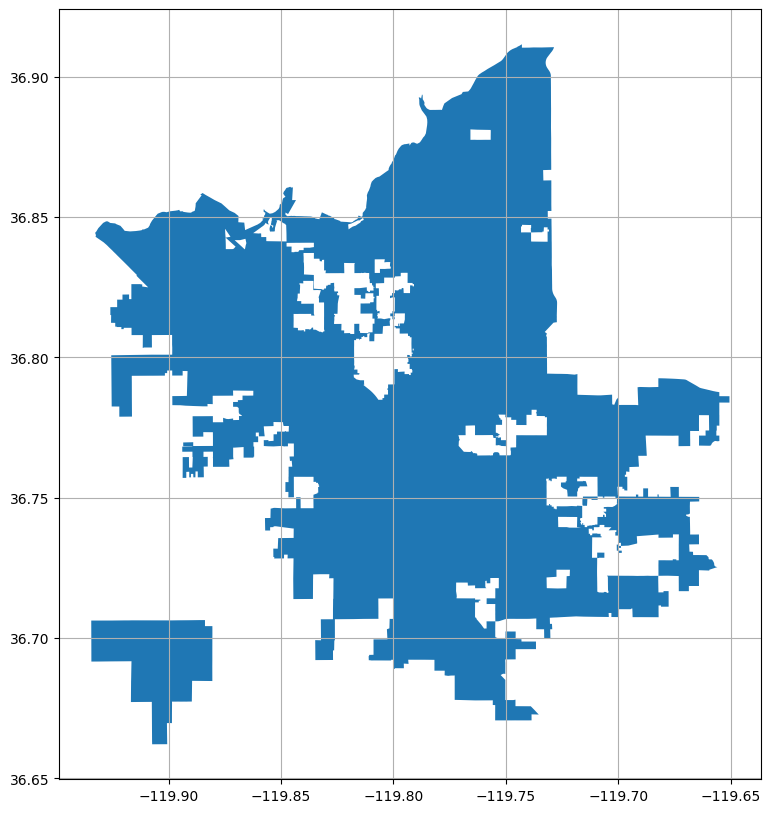

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax)
# turn on grid
ax.grid()
plt.show()

In [6]:
fresno_map.total_bounds

array([-119.93440971,   36.66216702, -119.65052167,   36.91154106])

In [7]:
lon_min = -119.95
lon_max = -119.65
lat_min = 36.65
lat_max = 36.95
ngrid_lon = 15
ngrid_lat = 15
gridsize_lon = (lon_max - lon_min) / ngrid_lon
gridsize_lat = (lat_max - lat_min) / ngrid_lat

## Load Data

In [8]:
fresno_data = load_city_data("Fresno")
fresno_data

,102014,167471,85495,6568,4551,163167,22403,44427,163163,42327,...,134292,97847,26241,134022,83213,18625,22751,155829,68263,46571
0,15.0,10.0,13.1,12.2,3.2,12.7,10.8,11.2,13.3,10.9,...,9.5,13.4,11.3,10.0,7.9,11.4,11.6,12.9,3.1,14.3
1,11.7,14.1,12.6,12.3,3.3,12.9,10.5,11.3,13.2,10.7,...,10.0,13.1,11.1,9.9,8.0,9.6,11.5,13.0,2.8,14.1
2,13.2,16.4,13.0,12.7,3.4,13.1,10.4,12.5,14.3,9.8,...,9.0,13.7,11.0,10.1,7.8,10.5,12.0,13.3,2.9,13.1
3,15.1,16.3,12.1,12.8,3.3,11.8,9.5,15.9,13.7,11.4,...,9.1,13.0,11.3,10.3,7.2,12.2,11.8,12.7,3.0,14.5
4,13.4,14.9,8.7,9.2,3.7,8.5,6.7,10.5,10.3,9.9,...,7.2,9.8,8.9,7.3,6.3,10.7,8.7,9.5,2.5,12.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,20.0,25.4,33.6,20.2,3.9,34.7,9.3,19.7,30.8,20.1,...,20.5,34.5,15.4,21.5,18.3,17.5,16.8,31.5,3.1,25.3
212,24.5,27.8,35.6,34.0,4.5,34.5,9.8,33.1,35.1,22.7,...,22.1,37.2,21.6,21.9,20.4,20.5,36.2,38.1,3.8,27.7
213,29.4,34.1,32.5,36.6,6.0,31.3,10.6,31.8,36.4,25.1,...,23.1,36.9,27.5,24.1,21.3,23.6,31.6,35.5,3.7,29.8
214,31.2,33.6,33.3,36.3,6.5,34.0,16.9,32.1,35.1,26.2,...,24.4,37.4,25.2,24.8,21.4,25.5,31.7,34.8,3.4,32.6


In [9]:
fresno_sensors = get_sensor_locations(fresno_data.columns)
fresno_sensors

,Sensor ID,Name,Latitude,Longitude,City
0,469,Sunnyside (interieur),36.724483,-119.701645,FRESNO
1,473,Sunnyside 93727,36.724483,-119.701645,FRESNO
2,134022,Dominion Villas,36.868164,-119.775700,FRESNO
3,134292,Alluvial/Chestnut,36.845753,-119.740380,FRESNO
4,4551,Van Ness Extension,36.811073,-119.838810,FRESNO
5,6194,CCA�Douglas and Kerckhoff�,36.741940,-119.673840,FRESNO
6,6568,IMPROVE_FRES2,36.785336,-119.772980,FRESNO
7,139384,Babigian and Parkway,36.799230,-119.875320,FRESNO
8,8854,CCA Root Access Hackerspace #1,36.762745,-119.798800,FRESNO
9,8892,CCA Root Access Hackerspace #2,36.762740,-119.798676,FRESNO


In [10]:
def check_in_box(lon, lat, box):
    return lon >= box[0] and lon <= box[2] and lat >= box[1] and lat <= box[3]

In [11]:
lons = np.linspace(lon_min, lon_max, ngrid_lon+1)
lats = np.linspace(lat_min, lat_max, ngrid_lat+1)
data_grid = {(lons[i], lats[j], lons[i+1], lats[j+1]): []
             for j in range(ngrid_lat) for i in range(ngrid_lon)}

for i in range(len(fresno_sensors)):
    lon, lat = fresno_sensors.loc[i, "Longitude"], fresno_sensors.loc[i, "Latitude"]
    sensor_id = fresno_sensors.loc[i, "Sensor ID"]
    val = fresno_data[str(sensor_id)].tolist()[-1]
    for box in data_grid.keys():
        if check_in_box(lon, lat, box):
            data_grid[box].append(val)

In [12]:
# Get training and test data for Gaussian Process
train_x = []
train_y = []
test_x = []
for box in data_grid.keys():
    test_x.append([box[0], box[1]])
    if len(data_grid[box]) > 0:
        train_x.append([box[0], box[1]])
        train_y.append(np.mean(data_grid[box]))
train_x = torch.tensor(train_x)
train_y = torch.tensor(train_y)
test_x = torch.tensor(test_x)
print(train_x.size(), train_y.size(), test_x.size())

torch.Size([29, 2]) torch.Size([29]) torch.Size([225, 2])


## Construct GP model

In [13]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
        
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [14]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)
training_iter = 20000
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

In [15]:
for i in range(training_iter):
    model.train()
    likelihood.train()
    optimizer.zero_grad()
    output = model(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    if i % 100 == 0:
        print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/20000 - Loss: 87.230
Iter 101/20000 - Loss: 11.713
Iter 201/20000 - Loss: 8.651
Iter 301/20000 - Loss: 7.194
Iter 401/20000 - Loss: 6.276
Iter 501/20000 - Loss: 5.327
Iter 601/20000 - Loss: 5.108
Iter 701/20000 - Loss: 4.955
Iter 801/20000 - Loss: 4.829
Iter 901/20000 - Loss: 4.725
Iter 1001/20000 - Loss: 4.636
Iter 1101/20000 - Loss: 4.559
Iter 1201/20000 - Loss: 4.492
Iter 1301/20000 - Loss: 4.434
Iter 1401/20000 - Loss: 4.381
Iter 1501/20000 - Loss: 4.335
Iter 1601/20000 - Loss: 4.292
Iter 1701/20000 - Loss: 4.254
Iter 1801/20000 - Loss: 4.219
Iter 1901/20000 - Loss: 4.188
Iter 2001/20000 - Loss: 4.158
Iter 2101/20000 - Loss: 4.131
Iter 2201/20000 - Loss: 4.106
Iter 2301/20000 - Loss: 4.083
Iter 2401/20000 - Loss: 4.062
Iter 2501/20000 - Loss: 4.042
Iter 2601/20000 - Loss: 4.023
Iter 2701/20000 - Loss: 4.005
Iter 2801/20000 - Loss: 3.989
Iter 2901/20000 - Loss: 3.973
Iter 3001/20000 - Loss: 3.959
Iter 3101/20000 - Loss: 3.945
Iter 3201/20000 - Loss: 3.932
Iter 3301/20000 - Lo

## Prediction and Visualization

In [19]:
model.eval()
likelihood.eval()
pred_y = model(train_x)
print('Train MAE: {}'.format(torch.mean(torch.abs(pred_y.mean - train_y))))

Train MAE: 6.091434119784663


/Users/shangjiedu/anaconda3/envs/env_ai/lib/python3.8/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


In [24]:
model.covar_module.base_kernel.lengthscale

tensor([[0.0554]], grad_fn=<SoftplusBackward0>)

In [20]:
model.eval()
likelihood.eval()
pred_y = model(test_x)

In [127]:
std = pred_y.stddev.detach().numpy().reshape(ngrid_lon, ngrid_lat)
entropy = 0.5 * np.log(2 * np.pi * np.power(std, 2)) + 0.5

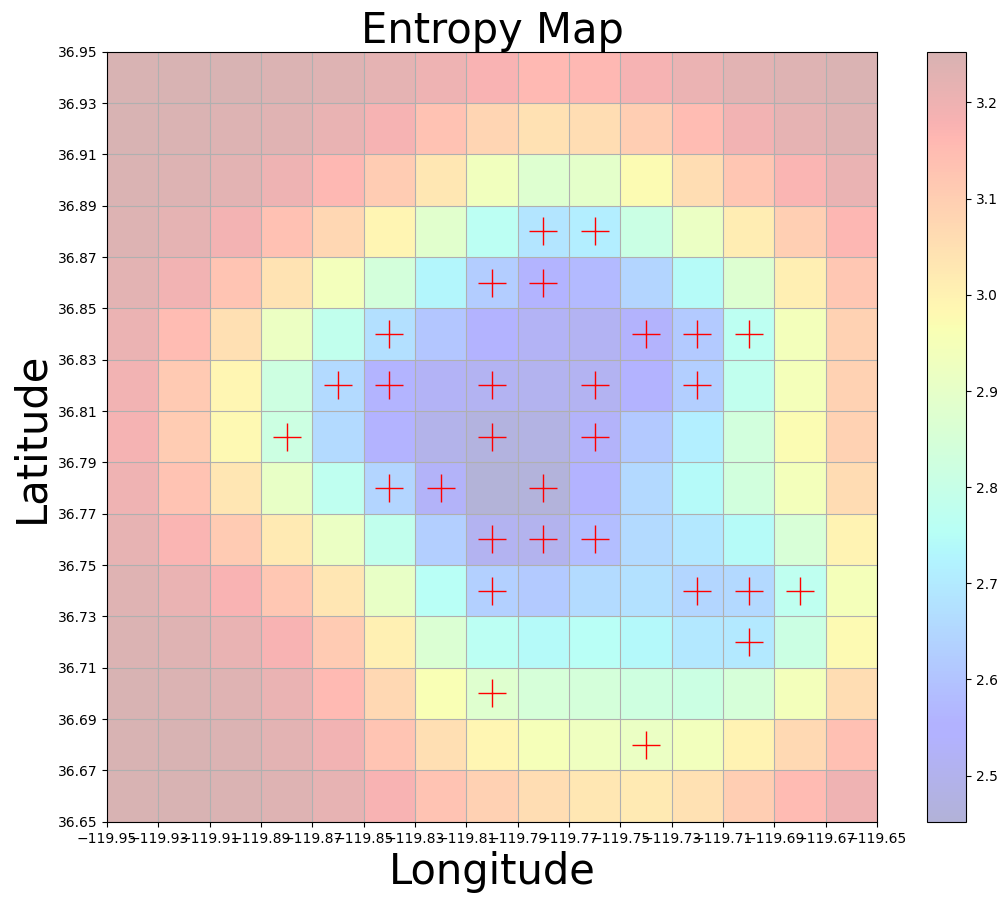

In [128]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
# fresno_map.plot(ax=ax, alpha=0.7, color='grey')
plt.imshow(entropy, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.3)
plt.colorbar()
plt.plot(train_x[:,0] + gridsize_lon/2, train_x[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
plt.show()

In [88]:
# Simulate add a new sensor
train_xnew = []
train_ynew = []
test_xnew = []
for box in data_grid.keys():
    test_xnew.append([box[0], box[1]])
    if len(data_grid[box]) > 0:
        train_xnew.append([box[0], box[1]])
        train_ynew.append(np.mean(data_grid[box]))
train_xnew.append([-119.9100, 36.7100])
train_ynew.append(25.6000)
train_xnew = torch.tensor(train_xnew)
train_ynew = torch.tensor(train_ynew)
test_xnew = torch.tensor(test_xnew)
print(train_xnew.size(), train_ynew.size(), test_xnew.size())

torch.Size([30, 2]) torch.Size([30]) torch.Size([225, 2])


In [91]:
likelihood_new = gpytorch.likelihoods.GaussianLikelihood()
model_new = ExactGPModel(train_xnew, train_ynew, likelihood_new)
training_iter = 20000
model_new.train()
likelihood_new.train()
optimizer = torch.optim.Adam(model_new.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood_new, model_new)

In [92]:
for i in range(training_iter):
    optimizer.zero_grad()
    output = model_new(train_xnew)
    loss = -mll(output, train_ynew)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/20000 - Loss: 84.350
Iter 2/20000 - Loss: 78.193
Iter 3/20000 - Loss: 72.585
Iter 4/20000 - Loss: 67.478
Iter 5/20000 - Loss: 62.825
Iter 6/20000 - Loss: 58.584
Iter 7/20000 - Loss: 54.713
Iter 8/20000 - Loss: 51.175
Iter 9/20000 - Loss: 47.934
Iter 10/20000 - Loss: 44.959
Iter 11/20000 - Loss: 42.223
Iter 12/20000 - Loss: 39.700
Iter 13/20000 - Loss: 37.369
Iter 14/20000 - Loss: 35.212
Iter 15/20000 - Loss: 33.217
Iter 16/20000 - Loss: 31.375
Iter 17/20000 - Loss: 29.688
Iter 18/20000 - Loss: 28.164
Iter 19/20000 - Loss: 26.817
Iter 20/20000 - Loss: 25.667
Iter 21/20000 - Loss: 24.726
Iter 22/20000 - Loss: 23.988
Iter 23/20000 - Loss: 23.423
Iter 24/20000 - Loss: 22.979
Iter 25/20000 - Loss: 22.600
Iter 26/20000 - Loss: 22.237
Iter 27/20000 - Loss: 21.860
Iter 28/20000 - Loss: 21.453
Iter 29/20000 - Loss: 21.018
Iter 30/20000 - Loss: 20.564
Iter 31/20000 - Loss: 20.105
Iter 32/20000 - Loss: 19.654
Iter 33/20000 - Loss: 19.225
Iter 34/20000 - Loss: 18.827
Iter 35/20000 - Loss: 1

In [93]:
model_new.eval()
likelihood_new.eval()
pred_ynew = model_new(test_xnew)

In [94]:
std_new = pred_ynew.stddev.detach().numpy().reshape(ngrid_lon, ngrid_lat)
entropy_new = 0.5 * np.log(2 * np.pi * np.power(std_new, 2)) + 0.5

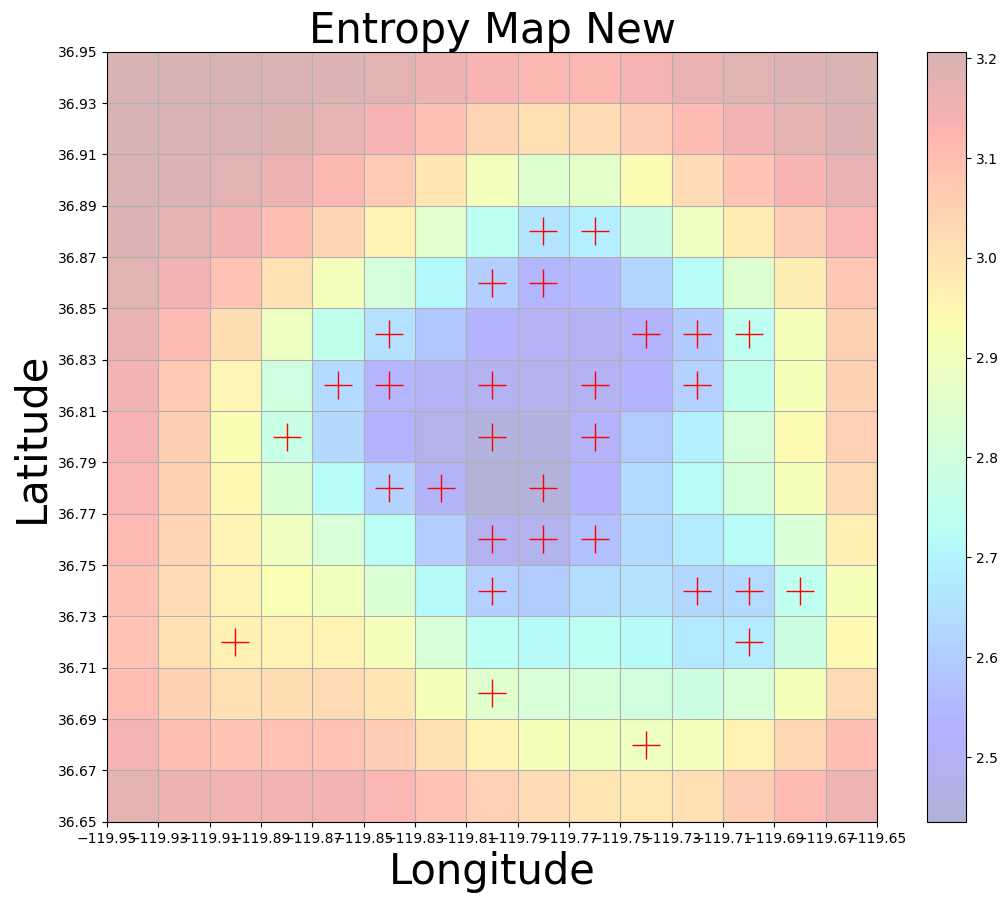

In [114]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
# fresno_map.plot(ax=ax, alpha=0.7, color='grey')
plt.imshow(entropy_new, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.3)
plt.colorbar()
plt.plot(train_xnew[:,0] + gridsize_lon/2, train_xnew[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map New", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
plt.show()

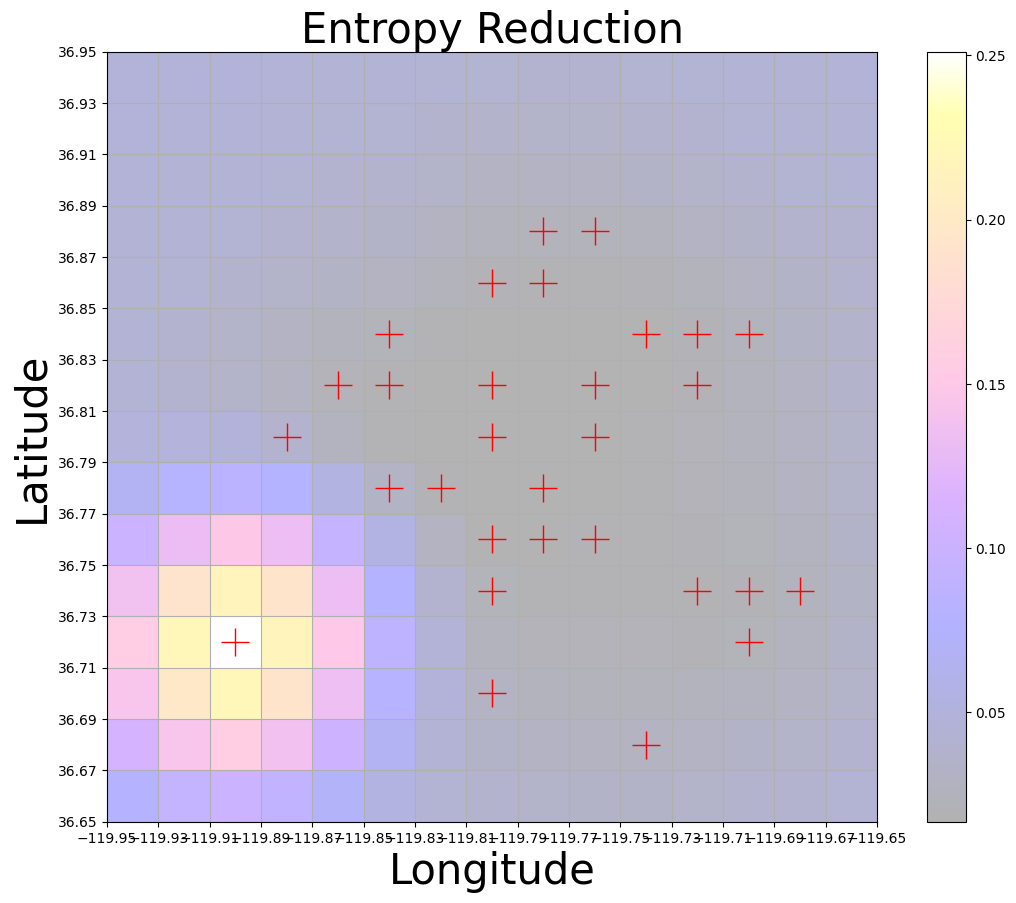

In [117]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
# fresno_map.plot(ax=ax, alpha=0.7, color='grey')
plt.imshow(entropy - entropy_new, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="gnuplot2", alpha=0.3)
plt.colorbar()
plt.plot(train_xnew[:,0] + gridsize_lon/2, train_xnew[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Reduction", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
plt.show()

# Compare remove center or corner

In [133]:
center_coord = (-119.81, 36.79)
corner_coord = (-119.75, 36.67)

## Remove center and corner

In [139]:
train_x1 = []
train_y1 = []
test_x1 = []
for box in data_grid.keys():
    test_x1.append([box[0], box[1]])
    if box[:2] == center_coord or box[:2] == corner_coord:
        continue
    if len(data_grid[box]) > 0:
        train_x1.append([box[0], box[1]])
        train_y1.append(np.mean(data_grid[box]))
train_x1 = torch.tensor(train_x1)
train_y1 = torch.tensor(train_y1)
test_x1 = torch.tensor(test_x1)
print(train_x1.size(), train_y1.size(), test_x1.size())

torch.Size([27, 2]) torch.Size([27]) torch.Size([225, 2])


In [144]:
likelihood1 = gpytorch.likelihoods.GaussianLikelihood()
model1 = ExactGPModel(train_x1, train_y1, likelihood1)
training_iter = 20000
model1.train()
likelihood1.train()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood1, model1)

In [145]:
for i in range(training_iter):
    optimizer.zero_grad()
    output = model1(train_x1)
    loss = -mll(output, train_y1)
    loss.backward()
    if i % 1000 == 0:
        print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/20000 - Loss: 92.259
Iter 1001/20000 - Loss: 4.742
Iter 2001/20000 - Loss: 4.233
Iter 3001/20000 - Loss: 4.017
Iter 4001/20000 - Loss: 3.898
Iter 5001/20000 - Loss: 3.825
Iter 6001/20000 - Loss: 3.780
Iter 7001/20000 - Loss: 3.752
Iter 8001/20000 - Loss: 3.736
Iter 9001/20000 - Loss: 3.728
Iter 10001/20000 - Loss: 3.724
Iter 11001/20000 - Loss: 3.723
Iter 12001/20000 - Loss: 3.723
Iter 13001/20000 - Loss: 3.723
Iter 14001/20000 - Loss: 3.723
Iter 15001/20000 - Loss: 3.722
Iter 16001/20000 - Loss: 3.721
Iter 17001/20000 - Loss: 3.687
Iter 18001/20000 - Loss: 3.687
Iter 19001/20000 - Loss: 3.687


In [146]:
model1.eval()
likelihood1.eval()
pred_y1 = model1(test_x1)
std1 = pred_y1.stddev.detach().numpy().reshape(ngrid_lon, ngrid_lat)
entropy1 = 0.5 * np.log(2 * np.pi * np.power(std1, 2)) + 0.5

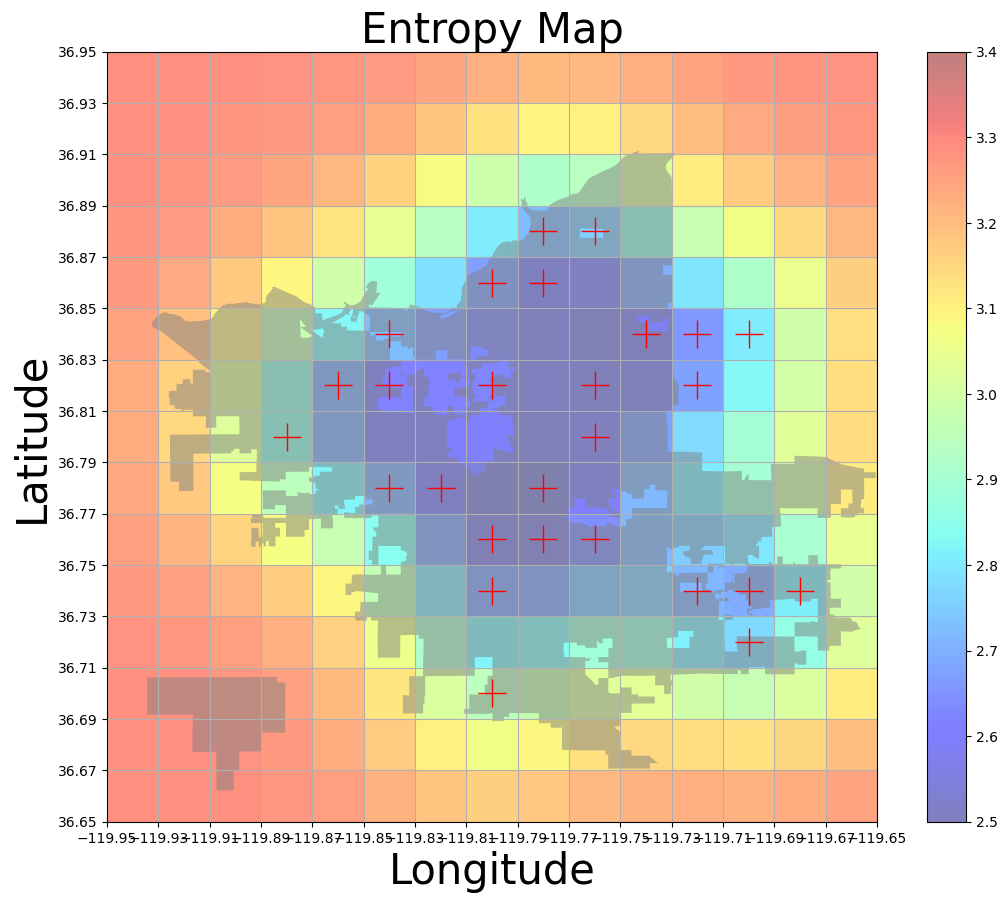

In [190]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
fresno_map.plot(ax=ax, alpha=0.5, color='grey')
plt.imshow(entropy1, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.5, vmin=2.5, vmax=3.4)
plt.colorbar()
plt.plot(train_x1[:,0] + gridsize_lon/2, train_x1[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
fig.savefig("./images/entropy_map.png")
plt.show()

## Add center

In [148]:
train_x2 = []
train_y2 = []
test_x2 = []
for box in data_grid.keys():
    test_x2.append([box[0], box[1]])
    if box[:2] == corner_coord:
        continue
    if len(data_grid[box]) > 0:
        train_x2.append([box[0], box[1]])
        train_y2.append(np.mean(data_grid[box]))
train_x2 = torch.tensor(train_x2)
train_y2 = torch.tensor(train_y2)
test_x2 = torch.tensor(test_x2)
print(train_x2.size(), train_y2.size(), test_x2.size())

torch.Size([28, 2]) torch.Size([28]) torch.Size([225, 2])


In [149]:
likelihood2 = gpytorch.likelihoods.GaussianLikelihood()
model2 = ExactGPModel(train_x2, train_y2, likelihood2)
training_iter = 20000
model2.train()
likelihood2.train()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood2, model2)

In [151]:
for i in range(training_iter):
    optimizer.zero_grad()
    output = model2(train_x2)
    loss = -mll(output, train_y2)
    loss.backward()
    if i % 1000 == 0:
        print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/20000 - Loss: 89.733
Iter 1001/20000 - Loss: 4.689
Iter 2001/20000 - Loss: 4.195
Iter 3001/20000 - Loss: 3.987
Iter 4001/20000 - Loss: 3.873
Iter 5001/20000 - Loss: 3.804
Iter 6001/20000 - Loss: 3.761
Iter 7001/20000 - Loss: 3.735
Iter 8001/20000 - Loss: 3.720
Iter 9001/20000 - Loss: 3.713
Iter 10001/20000 - Loss: 3.710
Iter 11001/20000 - Loss: 3.709
Iter 12001/20000 - Loss: 3.709
Iter 13001/20000 - Loss: 3.708
Iter 14001/20000 - Loss: 3.708
Iter 15001/20000 - Loss: 3.707
Iter 16001/20000 - Loss: 3.666
Iter 17001/20000 - Loss: 3.666
Iter 18001/20000 - Loss: 3.666
Iter 19001/20000 - Loss: 3.666


In [152]:
model2.eval()
likelihood2.eval()
pred_y2 = model2(test_x2)
std2 = pred_y2.stddev.detach().numpy().reshape(ngrid_lon, ngrid_lat)
entropy2 = 0.5 * np.log(2 * np.pi * np.power(std2, 2)) + 0.5

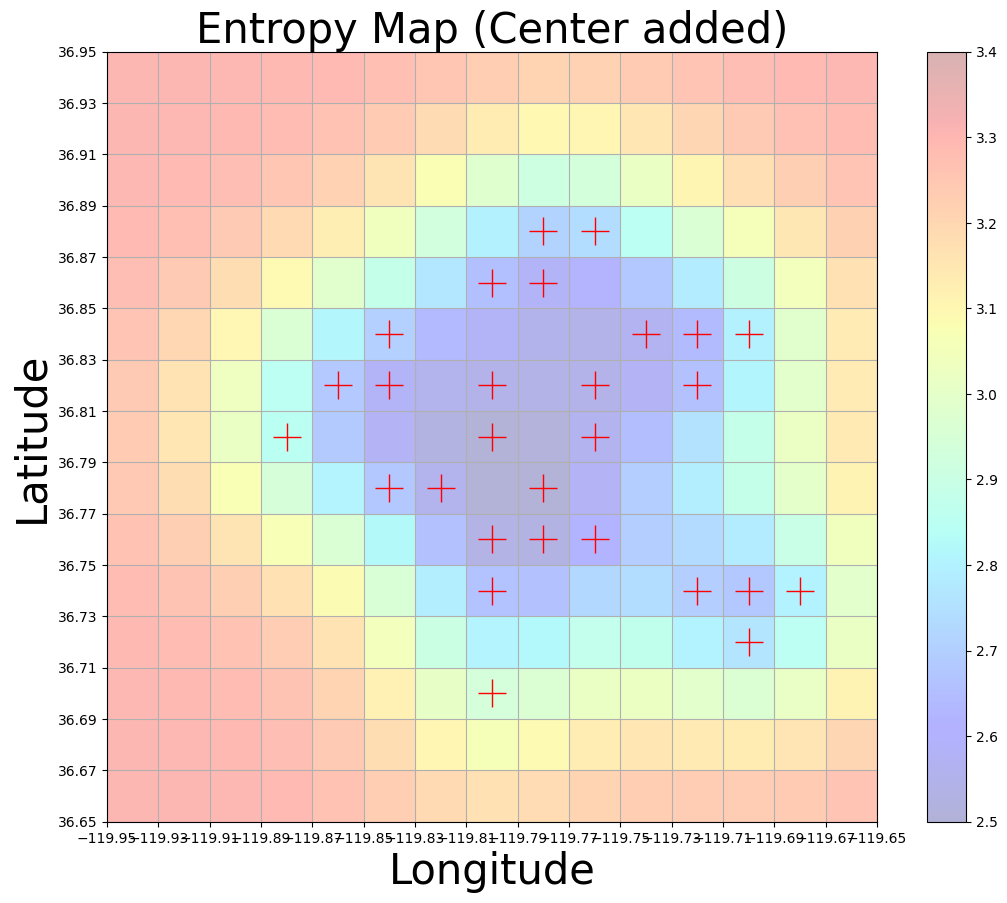

In [177]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
# fresno_map.plot(ax=ax, alpha=.7, color='#adb5bd')
plt.imshow(entropy2, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.3, vmin=2.5, vmax=3.4)
plt.colorbar()
plt.plot(train_x2[:,0] + gridsize_lon/2, train_x2[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map (Center added)", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
plt.show()

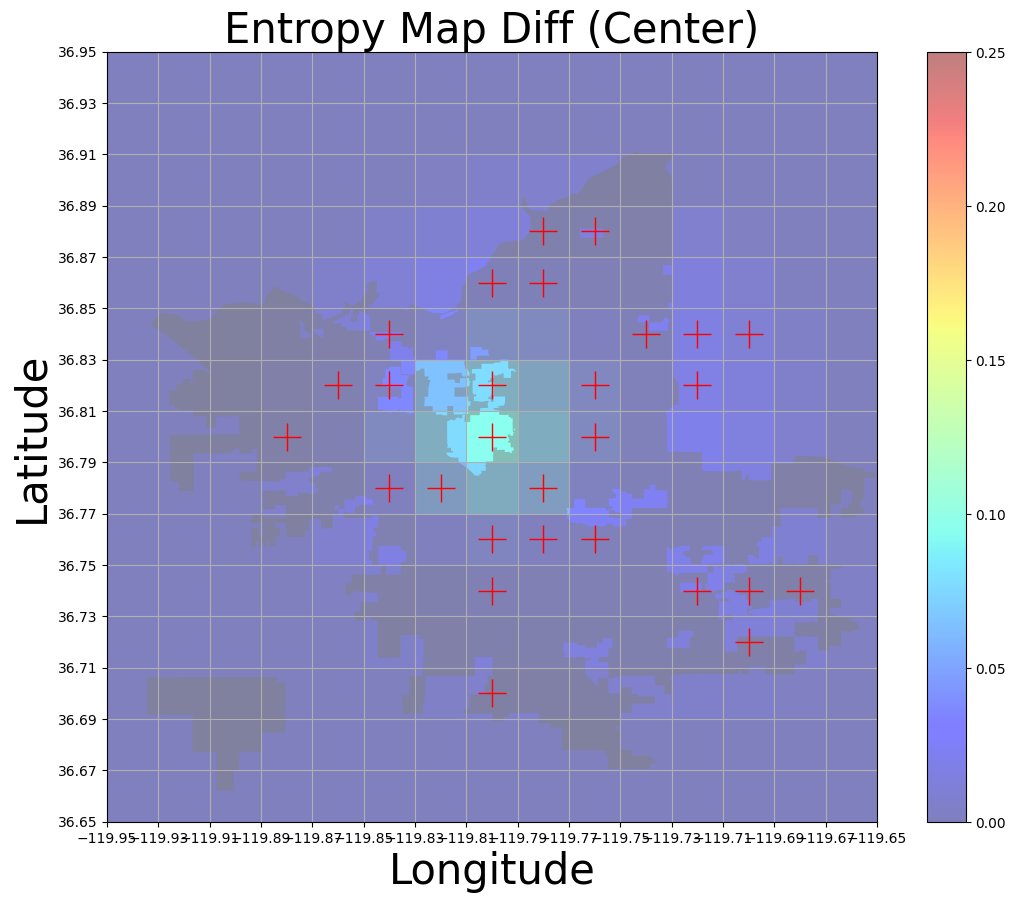

In [189]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
fresno_map.plot(ax=ax, alpha=0.5, color='grey')
plt.imshow(entropy1 - entropy2, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.5, vmin=0, vmax=0.25)
plt.colorbar()
plt.plot(train_x2[:,0] + gridsize_lon/2, train_x2[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map Diff (Center)", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
fig.savefig("./images/entropy_center_diff.png")
plt.show()

## Add corner

In [155]:
train_x3 = []
train_y3 = []
test_x3 = []
for box in data_grid.keys():
    test_x3.append([box[0], box[1]])
    if box[:2] == center_coord:
        continue
    if len(data_grid[box]) > 0:
        train_x3.append([box[0], box[1]])
        train_y3.append(np.mean(data_grid[box]))
train_x3 = torch.tensor(train_x3)
train_y3 = torch.tensor(train_y3)
test_x3 = torch.tensor(test_x3)
print(train_x3.size(), train_y3.size(), test_x3.size())

torch.Size([28, 2]) torch.Size([28]) torch.Size([225, 2])


In [156]:
likelihood3 = gpytorch.likelihoods.GaussianLikelihood()
model3 = ExactGPModel(train_x3, train_y3, likelihood3)
training_iter = 20000
model3.train()
likelihood3.train()
optimizer = torch.optim.Adam(model3.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood3, model3)

In [157]:
for i in range(training_iter):
    optimizer.zero_grad()
    output = model3(train_x3)
    loss = -mll(output, train_y3)
    loss.backward()
    if i % 1000 == 0:
        print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
    optimizer.step()

Iter 1/20000 - Loss: 89.618
Iter 1001/20000 - Loss: 4.686
Iter 2001/20000 - Loss: 4.194
Iter 3001/20000 - Loss: 3.987
Iter 4001/20000 - Loss: 3.873
Iter 5001/20000 - Loss: 3.804
Iter 6001/20000 - Loss: 3.761
Iter 7001/20000 - Loss: 3.735
Iter 8001/20000 - Loss: 3.721
Iter 9001/20000 - Loss: 3.714
Iter 10001/20000 - Loss: 3.711
Iter 11001/20000 - Loss: 3.710
Iter 12001/20000 - Loss: 3.710
Iter 13001/20000 - Loss: 3.710
Iter 14001/20000 - Loss: 3.709
Iter 15001/20000 - Loss: 3.709
Iter 16001/20000 - Loss: 3.708
Iter 17001/20000 - Loss: 3.677
Iter 18001/20000 - Loss: 3.677
Iter 19001/20000 - Loss: 3.677


In [158]:
model3.eval()
likelihood3.eval()
pred_y3 = model3(test_x3)
std3 = pred_y3.stddev.detach().numpy().reshape(ngrid_lon, ngrid_lat)
entropy3 = 0.5 * np.log(2 * np.pi * np.power(std3, 2)) + 0.5

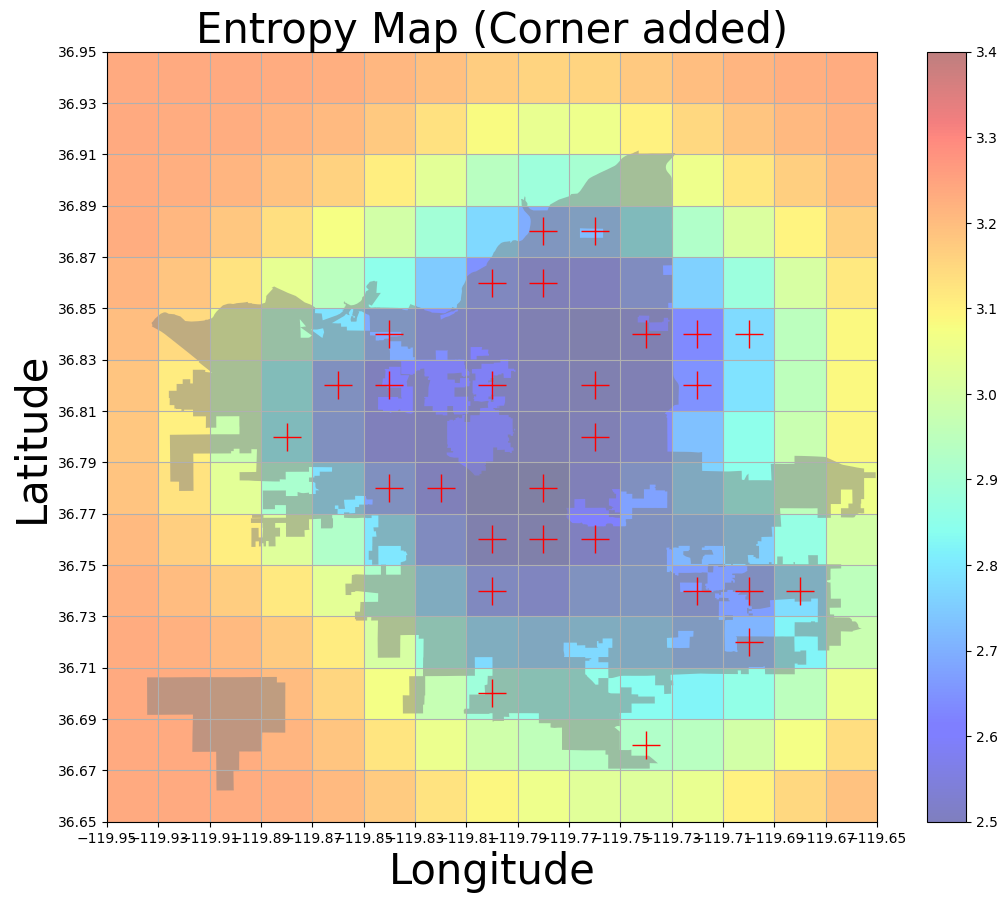

In [187]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
fresno_map.plot(ax=ax, alpha=0.5, color='grey')
plt.imshow(entropy3, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.5, vmin=2.5, vmax=3.4)
plt.colorbar()
plt.plot(train_x3[:,0] + gridsize_lon/2, train_x3[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map (Corner added)", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
fig.savefig("./images/entropy_corner.png")
plt.show()

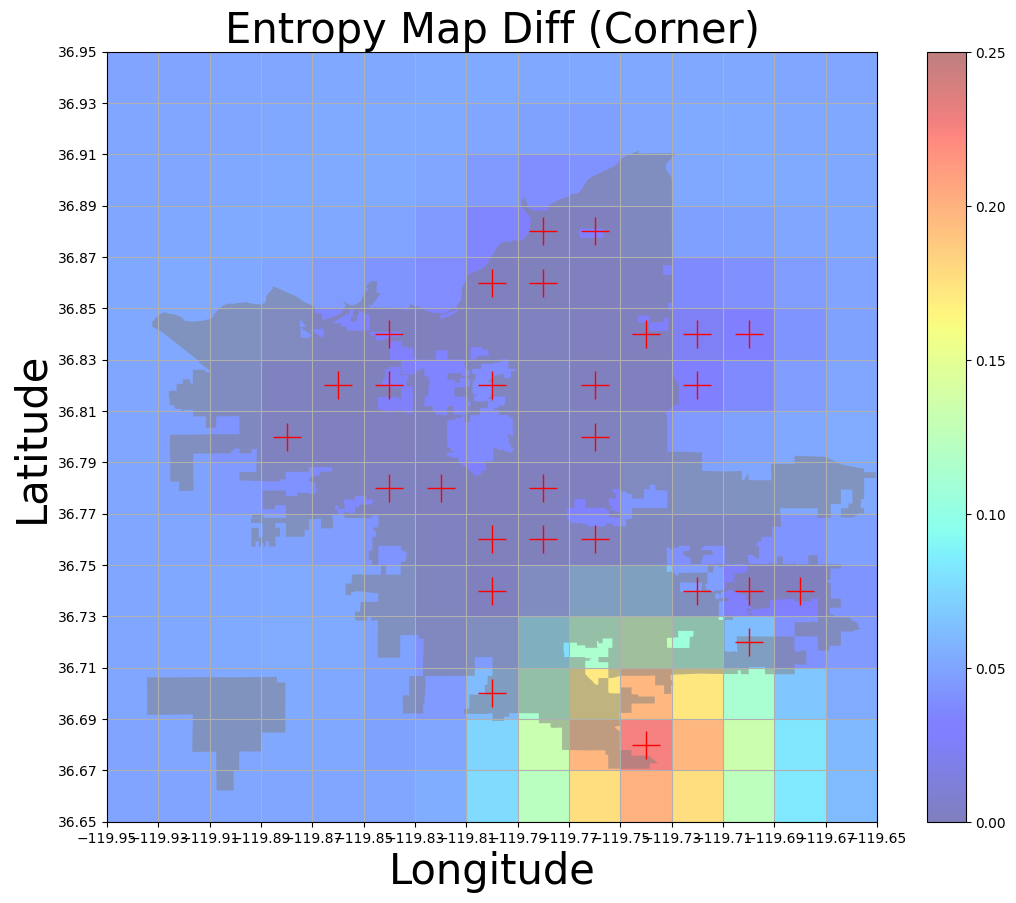

In [188]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
fresno_map.plot(ax=ax, alpha=0.5, color='grey')
plt.imshow(entropy1 - entropy3, extent=(lon_min, lon_max, lat_min, lat_max),
           origin="lower", cmap="jet", alpha=0.5, vmin=0, vmax=0.25)
plt.colorbar()
plt.plot(train_x3[:,0] + gridsize_lon/2, train_x3[:,1] + gridsize_lat/2, "r+", markersize=20)
ax.set_title("Entropy Map Diff (Corner)", fontsize=30)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
fig.savefig("./images/entropy_corner_diff.png")
plt.show()

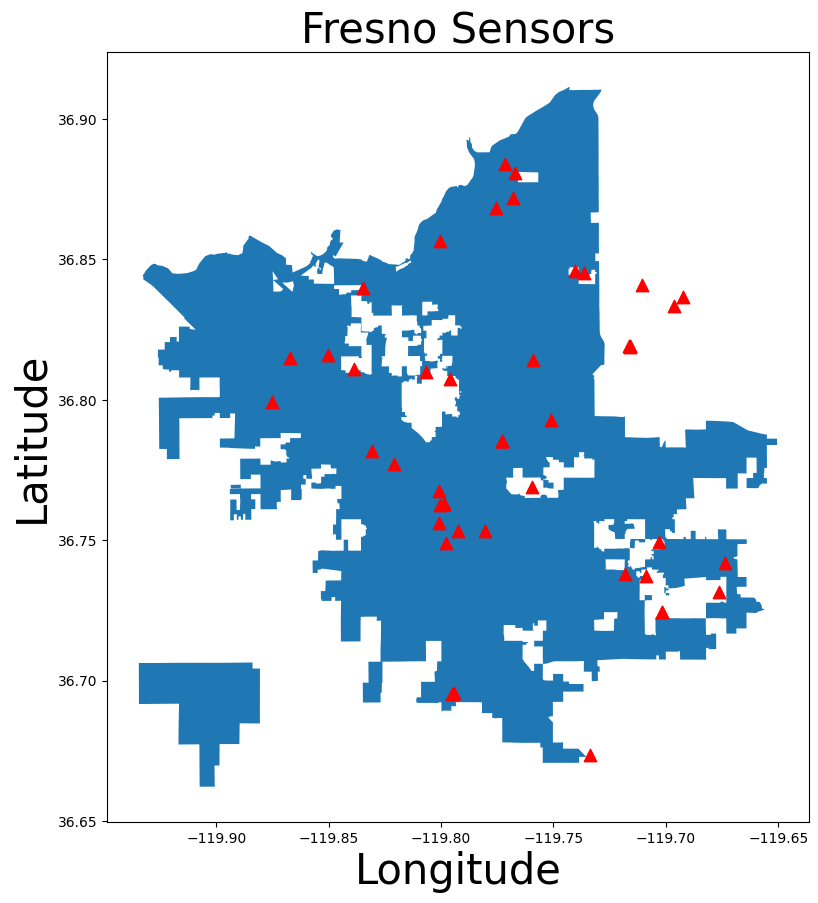

In [65]:
fig, ax = plt.subplots(figsize=(13, 10))
fresno_map.plot(ax=ax)
ax.scatter(fresno_sensors.loc[:, "Longitude"], fresno_sensors.loc[:, "Latitude"], marker="^", color="r", s=80)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
ax.set_title("Fresno Sensors", fontsize=30)
plt.show()

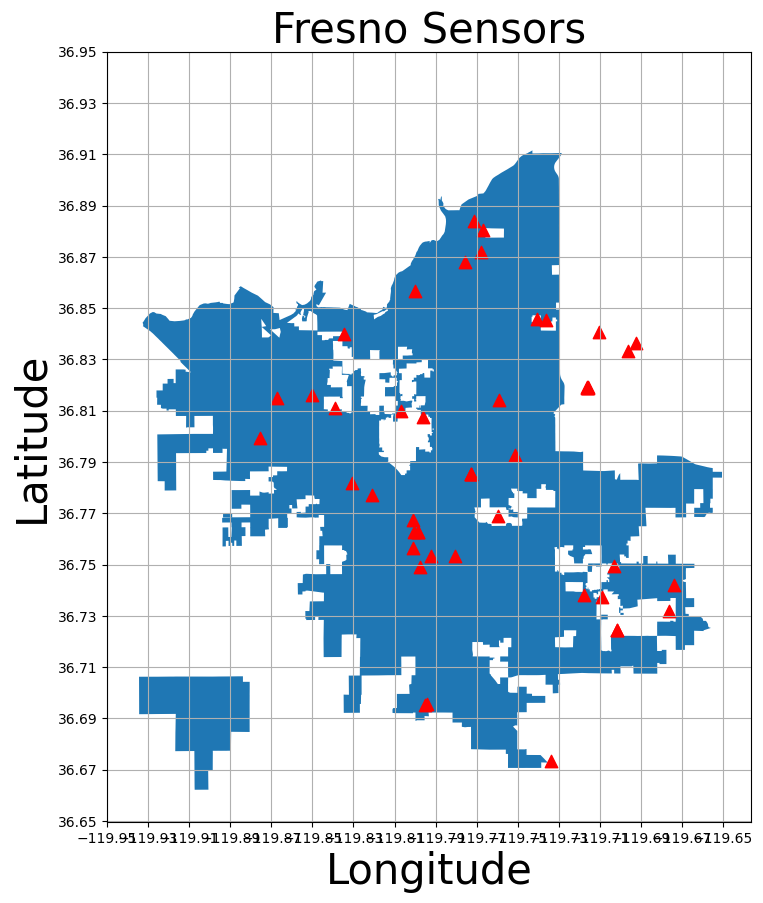

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax)
ax.scatter(fresno_sensors.loc[:, "Longitude"], fresno_sensors.loc[:, "Latitude"], marker="^", color="r", s=80)
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
ax.set_title("Fresno Sensors", fontsize=30)
plt.show()

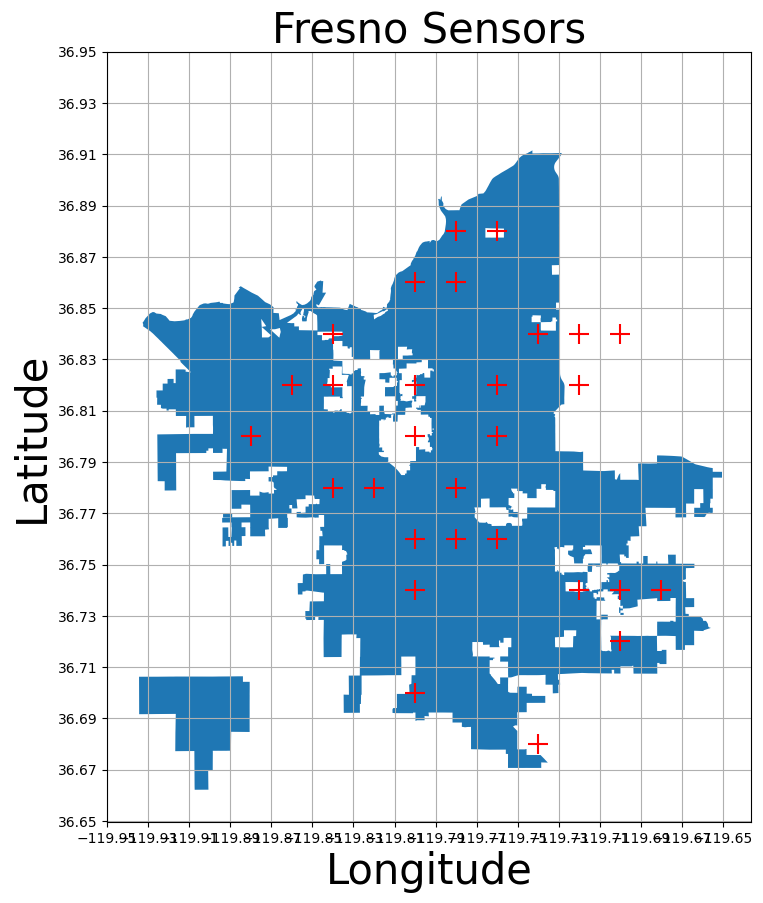

In [71]:
fig, ax = plt.subplots(figsize=(10, 10))
fresno_map.plot(ax=ax)
ax.scatter(train_x[:,0] + gridsize_lon/2, train_x[:,1] + gridsize_lat/2, marker="+", color="r", s=200)
ax.grid(True)
ax.set_xticks(lons)
ax.set_yticks(lats)
ax.set_xlabel("Longitude", fontsize=30)
ax.set_ylabel("Latitude", fontsize=30)
ax.set_title("Fresno Sensors", fontsize=30)
plt.show()